In [1]:
from matplotlib import cm

STREAM_BLUE = "#3182bd"
REM_CMAP = "RdYlBu_r"

POINT_GROUP_COLORS = {
    "low_rem_target": "#d62728",
    "riparian_target": "#1f77b4",
    "field_edge_target": "#ff7f0e",
    "high_rem_control": "#2ca02c",
}
GROUP_ORDER = ["low_rem_target", "riparian_target", "field_edge_target", "high_rem_control"]

STRATA_COLORS = {
    "riparian": "#1f77b4",
    "floodplain": "#aec7e8",
    "low_terrace": "#ffbb78",
    "upland": "#2ca02c",
}

N_CLUSTERS = 5
CLUSTER_COLORS = {i: cm.tab10(i / 10) for i in range(10)}


## §1 Setup

Load project configuration, set output paths, configure logging.


In [2]:
import json
import logging
import os
from pathlib import Path
import tomllib

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

from handily.points.cluster import (
    DEFAULT_CLUSTER_FEATURES,
    compute_cluster_stats,
    fit_gmm,
    fit_kmeans,
    select_clustering_features,
    standardize_features,
    sweep_kmeans,
    write_cluster_assignments,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

CONFIG_PATH = Path("beaverhead_config.toml")
with open(CONFIG_PATH, "rb") as _f:
    config = tomllib.load(_f)

# Mirror NB03 logic: points_out_dir key first, else out_dir/points
points_out_dir = config.get("points_out_dir") or os.path.join(config["out_dir"], "points")
print(f"points_out_dir: {points_out_dir}")

# Initialise variables so later cells are safe even if earlier ones are skipped
labels_km = labels_gmm = valid_index = X = X_scaled = scaler = cluster_stats = None
used_cols: list[str] = []
ps_geo = None


points_out_dir: /nas/handily/handily/beaverhead/outputs/points


## §2 Load & prepare data

Load `point_summary.parquet` and `points_static.parquet` produced by NB03 §8–10.


In [3]:
point_summary_path = os.path.join(points_out_dir, "point_summary.parquet")
points_static_path = os.path.join(points_out_dir, "points_static.parquet")

if not os.path.exists(point_summary_path):
    print(f"[SKIP] {point_summary_path} not found — run NB03 §8–10 first")
    point_summary = pd.DataFrame()
    points_static = gpd.GeoDataFrame()
else:
    point_summary = pd.read_parquet(point_summary_path)
    points_static = (
        gpd.read_parquet(points_static_path)
        if os.path.exists(points_static_path)
        else gpd.GeoDataFrame()
    )
    print(f"point_summary: {point_summary.shape}")
    print(f"points_static: {points_static.shape}")
    print(f"\npoint_summary columns:\n{list(point_summary.columns)}")


point_summary: (310, 24)
points_static: (310, 23)

point_summary columns:
['point_id', 'n_years', 'valid_years', 'irr_freq', 'irr_frac_mean', 'irr_frac_std', 'n_irr_years', 'aet_mean', 'aet_std', 'ndvi_amp_mean', 'ndvi_peak_mean', 'ndvi_mean_mean', 'ndvi_amp_std', 'rem_at_sample', 'sample_group', 'rem_bin', 'in_irrigated_lands', 'is_low_rem_target', 'is_riparian_target', 'is_field_edge_target', 'is_high_rem_control', 'low_rem_flag', 'high_rem_control_flag', 'riparian_flag']


In [4]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty — run NB03 §10 first")
else:
    static_geo_cols = [c for c in ["point_id", "geometry", "sample_group"] if c in points_static.columns]
    merged = point_summary.merge(points_static[static_geo_cols], on="point_id", how="left")
    if "geometry" in merged.columns:
        ps_geo = gpd.GeoDataFrame(merged, geometry="geometry", crs=points_static.crs)
    else:
        ps_geo = gpd.GeoDataFrame(merged)
    print(f"ps_geo shape: {ps_geo.shape}")
    print("\nsample_group counts:")
    if "sample_group" in ps_geo.columns:
        print(ps_geo["sample_group"].value_counts())
    print("\nvalid_years distribution:")
    print(ps_geo["valid_years"].describe().round(2))


ps_geo shape: (310, 26)

sample_group counts:

valid_years distribution:
count    310.0
mean       5.0
std        0.0
min        5.0
25%        5.0
50%        5.0
75%        5.0
max        5.0
Name: valid_years, dtype: float64


## §3 Feature correlations & missingness

Inspect which features are available, how many NaN values each has, and how features correlate.


Feature missingness:
                 present  missing  pct_missing
irr_freq            310        0          0.0
aet_mean            310        0          0.0
ndvi_amp_mean       310        0          0.0
ndvi_amp_std        310        0          0.0
ndvi_peak_mean      310        0          0.0
rem_at_sample       310        0          0.0


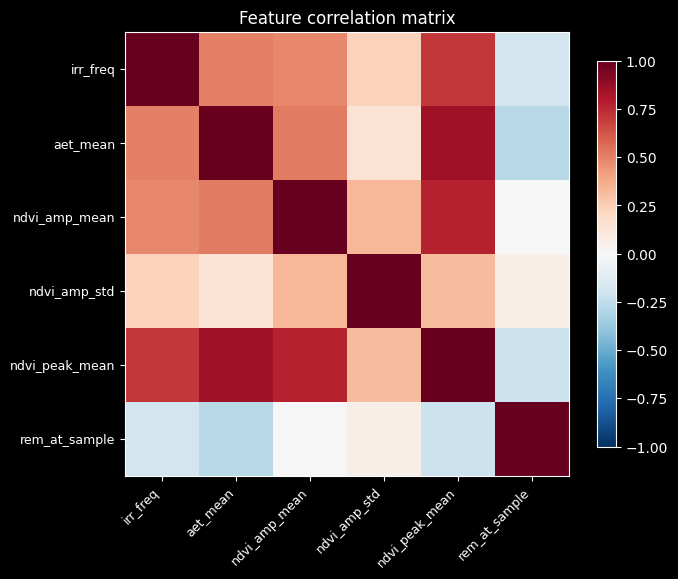

In [5]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
else:
    feat_cols = [c for c in DEFAULT_CLUSTER_FEATURES if c in point_summary.columns]
    miss = pd.DataFrame({
        "present": [point_summary[c].notna().sum() for c in feat_cols],
        "missing": [point_summary[c].isna().sum() for c in feat_cols],
        "pct_missing": [round(point_summary[c].isna().mean() * 100, 1) for c in feat_cols],
    }, index=feat_cols)
    print("Feature missingness:\n", miss)
    
    corr = point_summary[feat_cols].corr()
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(len(feat_cols)))
    ax.set_yticks(range(len(feat_cols)))
    ax.set_xticklabels(feat_cols, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(feat_cols, fontsize=9)
    ax.set_title("Feature correlation matrix")
    plt.tight_layout()
    plt.show()


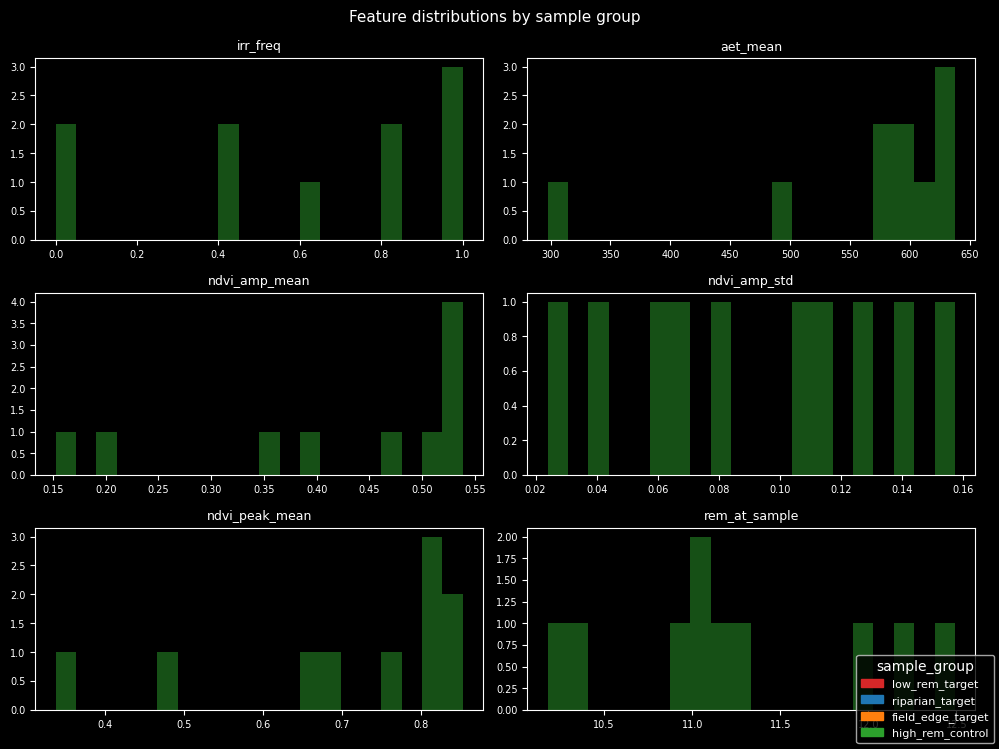

In [6]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
else:
    feat_cols = [c for c in DEFAULT_CLUSTER_FEATURES if c in point_summary.columns]
    n_cols_grid = 2
    n_rows_grid = int(np.ceil(len(feat_cols) / n_cols_grid))
    fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(10, n_rows_grid * 2.5))
    axes = np.array(axes).flatten()

    for ax, col in zip(axes, feat_cols):
        for grp in GROUP_ORDER:
            if "sample_group" in point_summary.columns:
                sub = point_summary.loc[point_summary["sample_group"] == grp, col].dropna()
            else:
                sub = point_summary[col].dropna()
            if len(sub) > 0:
                ax.hist(sub, bins=20, alpha=0.5, label=grp,
                        color=POINT_GROUP_COLORS.get(grp, "gray"))
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)

    for ax in axes[len(feat_cols):]:
        ax.set_visible(False)

    handles = [plt.Rectangle((0, 0), 1, 1, color=POINT_GROUP_COLORS.get(g, "gray")) for g in GROUP_ORDER]
    fig.legend(handles, GROUP_ORDER, loc="lower right", fontsize=8, title="sample_group")
    fig.suptitle("Feature distributions by sample group", fontsize=11)
    plt.tight_layout()
    plt.show()


## §4 K-sweep diagnostic

Evaluate K-means for k=2..10 using inertia, silhouette score, and Davies-Bouldin index to
identify the optimal number of clusters.


WARNING handily.points.cluster: Dropping absent feature columns: ['etf_mean', 'etf_std']


Clustering on 6 features: ['irr_freq', 'aet_mean', 'ndvi_amp_mean', 'ndvi_amp_std', 'ndvi_peak_mean', 'rem_at_sample']
Valid points: 310 / 310

K sweep results:
      inertia  silhouette  davies_bouldin
k                                        
2   1226.6811      0.3186          1.2306
3    993.6466      0.2664          1.3229
4    797.3642      0.3020          1.1710
5    689.6271      0.3237          1.0497
6    587.1769      0.3134          1.0391
7    501.4112      0.3303          0.9787
8    437.7864      0.3514          0.9176
9    400.0757      0.3444          0.9862
10   365.8063      0.3097          1.0044

Best k by silhouette: 8


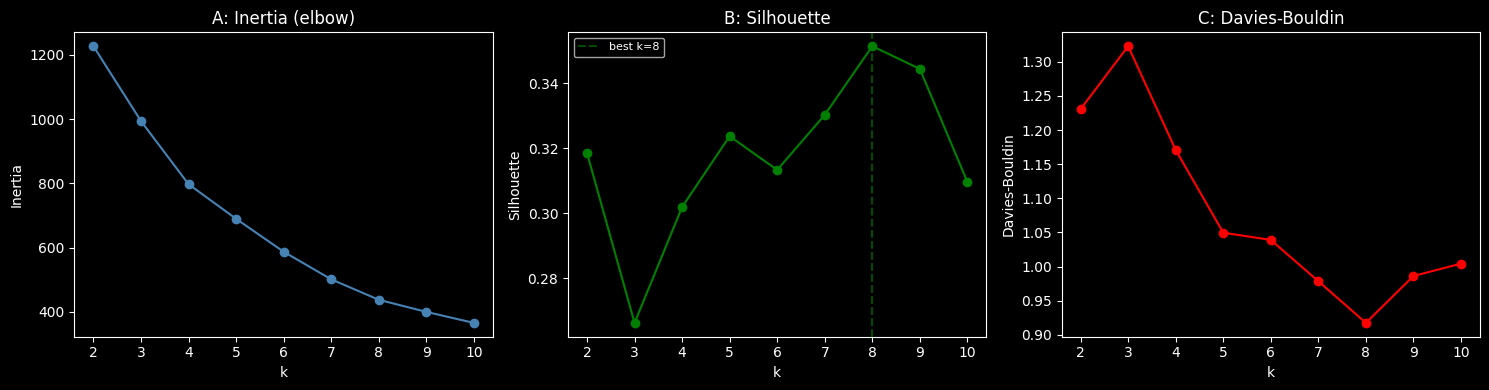

In [7]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
else:
    valid_index, X, used_cols = select_clustering_features(point_summary)
    X_scaled, scaler = standardize_features(X)
    print(f"Clustering on {len(used_cols)} features: {used_cols}")
    print(f"Valid points: {len(valid_index)} / {len(point_summary)}")

    sweep = sweep_kmeans(X_scaled)
    best_k = int(sweep["silhouette"].idxmax())
    print(f"\nK sweep results:\n{sweep.round(4)}")
    print(f"\nBest k by silhouette: {best_k}")

    fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(15, 4))
    ax_a.plot(sweep.index, sweep["inertia"], "o-", color="steelblue")
    ax_a.set_xlabel("k"); ax_a.set_ylabel("Inertia"); ax_a.set_title("A: Inertia (elbow)")

    ax_b.plot(sweep.index, sweep["silhouette"], "o-", color="green")
    ax_b.axvline(best_k, color="green", linestyle="--", alpha=0.6, label=f"best k={best_k}")
    ax_b.set_xlabel("k"); ax_b.set_ylabel("Silhouette"); ax_b.set_title("B: Silhouette")
    ax_b.legend(fontsize=8)

    ax_c.plot(sweep.index, sweep["davies_bouldin"], "o-", color="red")
    ax_c.set_xlabel("k"); ax_c.set_ylabel("Davies-Bouldin"); ax_c.set_title("C: Davies-Bouldin")
    plt.tight_layout()
    plt.show()


## §5 K-means clustering

Fit K-means with k=N_CLUSTERS and inspect the resulting cluster assignments.


In [8]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
elif valid_index is None:
    print("[SKIP] run §4 first to compute valid_index and X_scaled")
else:
    labels_km = fit_kmeans(X_scaled, k=N_CLUSTERS)
    sil_km = silhouette_score(X_scaled, labels_km)
    print(f"K-means silhouette (k={N_CLUSTERS}): {sil_km:.4f}")

    cluster_counts = pd.Series(labels_km, name="cluster").value_counts().sort_index()
    print(f"\nCluster sizes:\n{cluster_counts}")

    cluster_stats = compute_cluster_stats(point_summary, valid_index, labels_km, used_cols)
    mean_cols = [c for c in cluster_stats.columns if c.endswith("_mean")]
    print(f"\nCluster means:\n{cluster_stats[mean_cols].round(3)}")


K-means silhouette (k=5): 0.3172

Cluster sizes:
cluster
0    105
1    116
2      9
3     71
4      9
Name: count, dtype: int64

Cluster means:
         irr_freq_mean  aet_mean_mean  ndvi_amp_mean_mean  ndvi_amp_std_mean  \
cluster                                                                        
0                0.998     779.653015               0.410              0.079   
1                0.893     626.330994               0.303              0.067   
2                0.000     426.243988               0.172              0.039   
3                0.175     559.419983               0.269              0.058   
4                0.778     610.044006               0.476              0.112   

         ndvi_peak_mean_mean  rem_at_sample_mean  
cluster                                           
0                      0.886               1.320  
1                      0.705               1.519  
2                      0.404               8.656  
3                      0.602            

## §6 Cluster characterization — violin plots

Distribution of each clustering feature per cluster (violins), and `sample_group` composition
of each cluster (stacked bar).


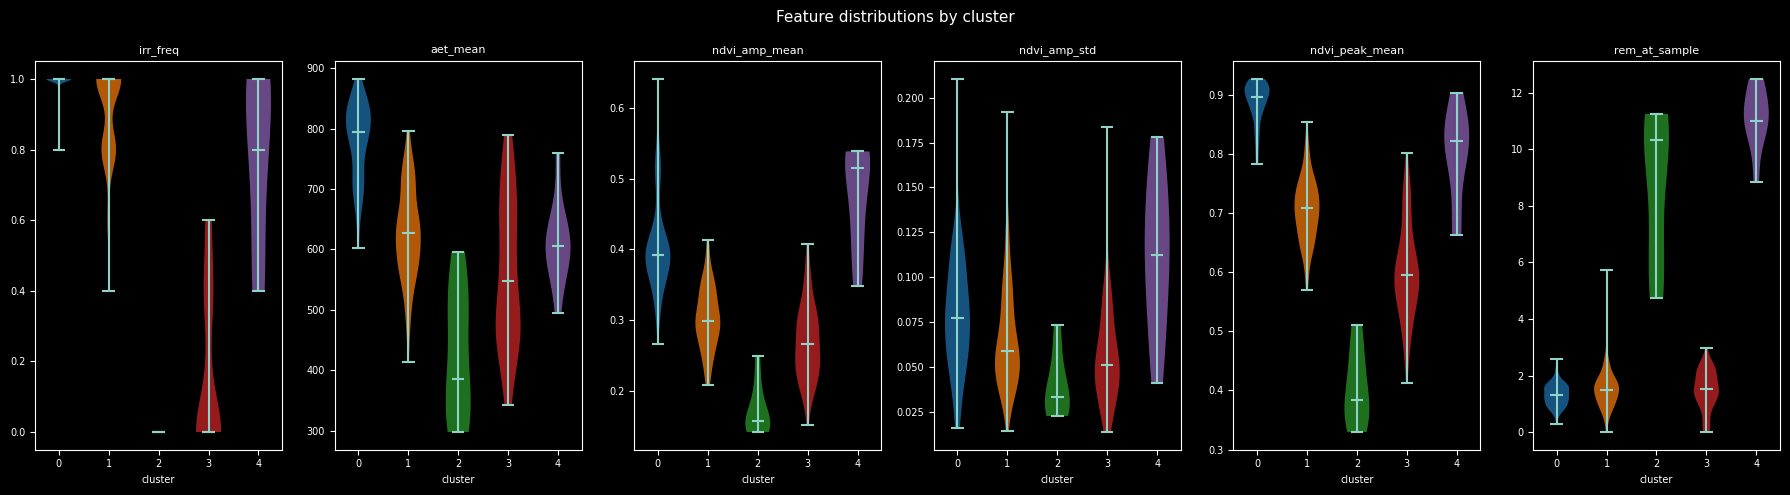

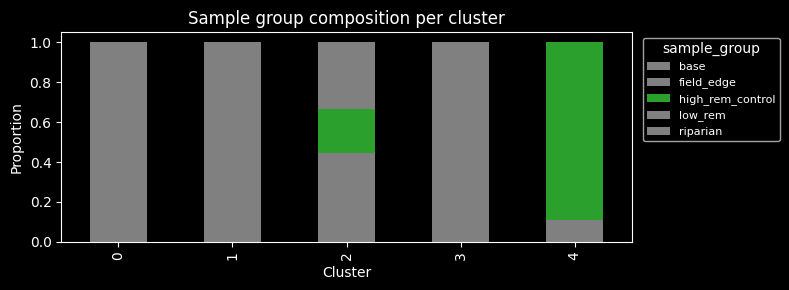

In [9]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
elif labels_km is None:
    print("[SKIP] run §5 first")
else:
    sub_df = point_summary.loc[valid_index, used_cols].copy()
    sub_df["cluster"] = labels_km

    n_feat = len(used_cols)
    fig, axes = plt.subplots(1, n_feat, figsize=(3 * n_feat, 5))
    if n_feat == 1:
        axes = [axes]

    for ax, col in zip(axes, used_cols):
        parts, positions = [], []
        for cid in sorted(sub_df["cluster"].unique()):
            vals = sub_df.loc[sub_df["cluster"] == cid, col].replace([np.inf, -np.inf], np.nan).dropna()
            if len(vals) >= 2:
                parts.append(vals.values)
                positions.append(cid)
        if parts:
            vp = ax.violinplot(parts, positions=positions, showmedians=True)
            for i, pc in enumerate(vp["bodies"]):
                pc.set_facecolor(CLUSTER_COLORS[positions[i]])
                pc.set_alpha(0.7)
        ax.set_title(col, fontsize=8)
        ax.set_xlabel("cluster", fontsize=7)
        ax.tick_params(labelsize=7)

    fig.suptitle("Feature distributions by cluster", fontsize=11)
    plt.tight_layout()
    plt.show()

    if "sample_group" in point_summary.columns:
        ct = pd.crosstab(
            pd.Series(labels_km, index=valid_index, name="cluster"),
            point_summary.loc[valid_index, "sample_group"],
            normalize="index",
        )
        ct.plot(kind="bar", stacked=True, figsize=(8, 3),
                color=[POINT_GROUP_COLORS.get(g, "gray") for g in ct.columns])
        plt.title("Sample group composition per cluster")
        plt.ylabel("Proportion")
        plt.xlabel("Cluster")
        plt.legend(title="sample_group", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
        plt.tight_layout()
        plt.show()


## §7 Radar chart

Normalized feature profiles per cluster shown as closed polygons on polar axes.


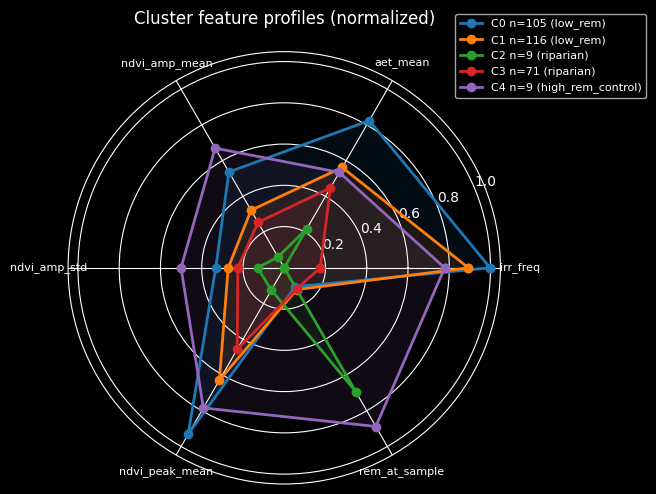

In [10]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
elif labels_km is None:
    print("[SKIP] run §5 first")
else:
    sub_df = point_summary.loc[valid_index, used_cols].copy()
    sub_df["cluster"] = labels_km

    col_min = sub_df[used_cols].min()
    col_max = sub_df[used_cols].max()
    col_range = (col_max - col_min).replace(0, 1)
    sub_norm = (sub_df[used_cols] - col_min) / col_range
    sub_norm["cluster"] = labels_km

    n_feat = len(used_cols)
    angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"polar": True})
    for cid in sorted(sub_df["cluster"].unique()):
        vals = sub_norm.loc[sub_norm["cluster"] == cid, used_cols].mean().values.tolist()
        vals += vals[:1]
        n_pts = int((labels_km == cid).sum())
        if "sample_group" in point_summary.columns:
            dominant = (
                point_summary.loc[valid_index[labels_km == cid], "sample_group"]
                .mode().iloc[0]
            )
            label = f"C{cid} n={n_pts} ({dominant})"
        else:
            label = f"C{cid} n={n_pts}"
        ax.plot(angles, vals, "o-", color=CLUSTER_COLORS[cid], label=label, linewidth=2)
        ax.fill(angles, vals, color=CLUSTER_COLORS[cid], alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(used_cols, fontsize=8)
    ax.set_title("Cluster feature profiles (normalized)", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
    plt.tight_layout()
    plt.show()


## §8 PCA biplot

Project the clustering features to 2D with PCA. Left panel: points coloured by cluster.
Right panel: feature loading vectors.


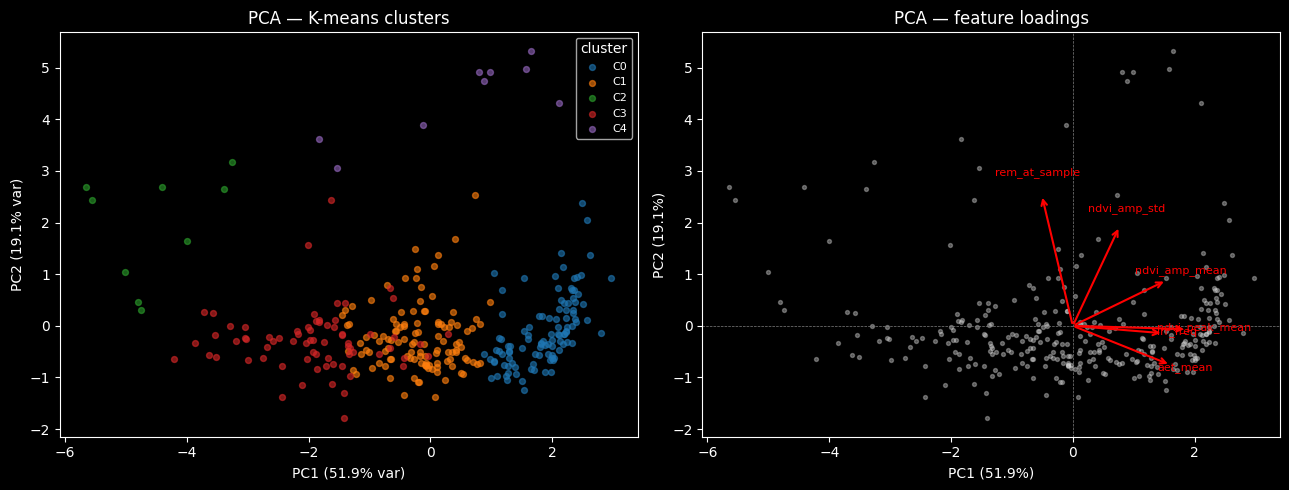

In [11]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
elif labels_km is None:
    print("[SKIP] run §5 first")
else:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    var_explained = pca.explained_variance_ratio_ * 100

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 5))

    for cid in sorted(np.unique(labels_km)):
        mask = labels_km == cid
        ax_l.scatter(X_pca[mask, 0], X_pca[mask, 1],
                     color=CLUSTER_COLORS[cid], label=f"C{cid}", s=18, alpha=0.6)
    ax_l.set_xlabel(f"PC1 ({var_explained[0]:.1f}% var)")
    ax_l.set_ylabel(f"PC2 ({var_explained[1]:.1f}% var)")
    ax_l.set_title("PCA — K-means clusters")
    ax_l.legend(fontsize=8, title="cluster")

    ax_r.scatter(X_pca[:, 0], X_pca[:, 1], color="lightgrey", s=8, alpha=0.4)
    loadings = pca.components_.T
    scale = float(np.abs(X_pca).max()) * 0.6
    for i, feat in enumerate(used_cols):
        ax_r.annotate(
            "", xy=(loadings[i, 0] * scale, loadings[i, 1] * scale), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
        )
        ax_r.text(loadings[i, 0] * scale * 1.15, loadings[i, 1] * scale * 1.15,
                  feat, fontsize=8, color="red", ha="center")
    ax_r.set_xlabel(f"PC1 ({var_explained[0]:.1f}%)")
    ax_r.set_ylabel(f"PC2 ({var_explained[1]:.1f}%)")
    ax_r.set_title("PCA — feature loadings")
    ax_r.axhline(0, color="grey", lw=0.5, ls="--")
    ax_r.axvline(0, color="grey", lw=0.5, ls="--")
    plt.tight_layout()
    plt.show()


## §9 Cluster stability

Assess how consistently K-means partitions the data across 10 random seeds for k=3..7.
Higher median silhouette + narrower spread indicates a more stable partition.


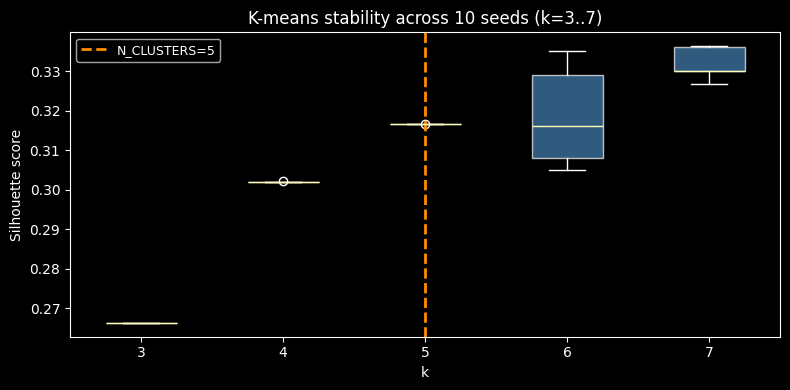

In [12]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
elif X_scaled is None:
    print("[SKIP] run §4 first")
else:
    stability_records = []
    for k_stab in range(3, 8):
        for seed in range(10):
            lbl = fit_kmeans(X_scaled, k=k_stab, random_state=seed)
            sil = silhouette_score(X_scaled, lbl)
            stability_records.append({"k": k_stab, "seed": seed, "silhouette": sil})
    stability = pd.DataFrame(stability_records)

    fig, ax = plt.subplots(figsize=(8, 4))
    k_vals = sorted(stability["k"].unique())
    data_per_k = [stability.loc[stability["k"] == k_stab, "silhouette"].values for k_stab in k_vals]
    bp = ax.boxplot(data_per_k, positions=k_vals, widths=0.5, patch_artist=True)
    for patch, k_stab in zip(bp["boxes"], k_vals):
        patch.set_facecolor("orange" if k_stab == N_CLUSTERS else "steelblue")
        patch.set_alpha(0.7)
    ax.axvline(N_CLUSTERS, color="darkorange", lw=2, ls="--", label=f"N_CLUSTERS={N_CLUSTERS}")
    ax.set_xlabel("k")
    ax.set_ylabel("Silhouette score")
    ax.set_title("K-means stability across 10 seeds (k=3..7)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


## §10 GMM comparison

Fit a Gaussian Mixture Model with the same k and compare assignments to K-means via the
Adjusted Rand Index (ARI). Points where assignments differ are shown as black crosses on a map.


INFO rasterio._env: GDAL signalled an error: err_no=4, msg='data/rem/rem.tif: No such file or directory'


Adjusted Rand Index (K-means vs GMM, k=5): 0.4690
Divergent assignments: 298 / 310


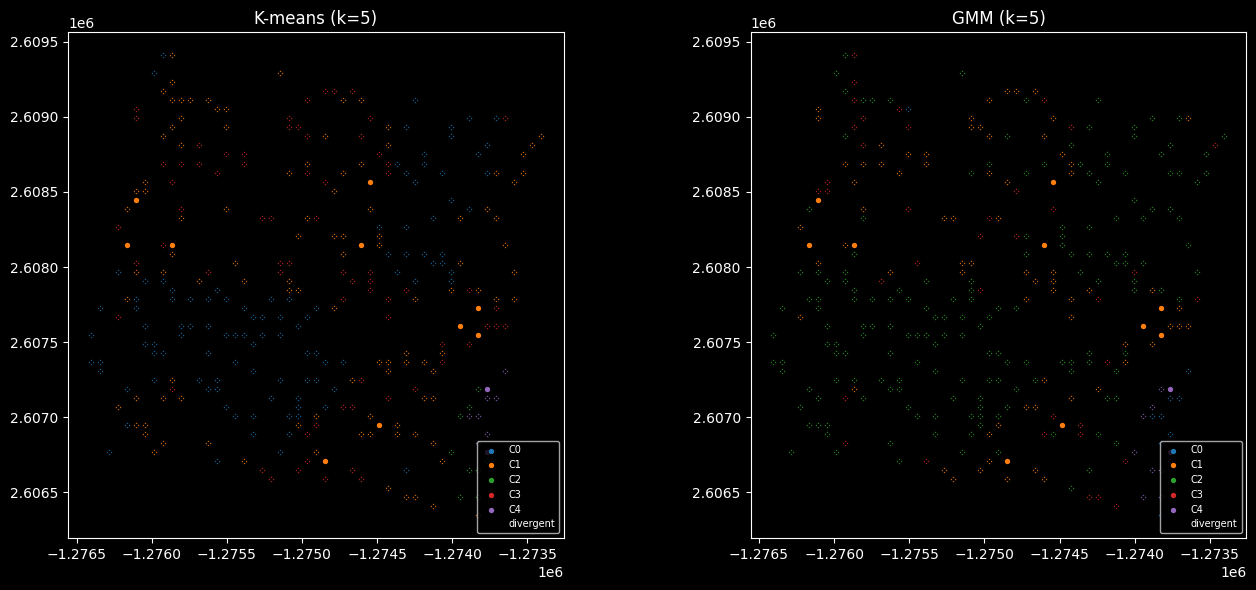

In [13]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
elif labels_km is None:
    print("[SKIP] run §5 first")
else:
    labels_gmm = fit_gmm(X_scaled, k=N_CLUSTERS)
    ari = adjusted_rand_score(labels_km, labels_gmm)
    print(f"Adjusted Rand Index (K-means vs GMM, k={N_CLUSTERS}): {ari:.4f}")
    print(f"Divergent assignments: {(labels_km != labels_gmm).sum()} / {len(labels_km)}")

    if ps_geo is not None and "geometry" in ps_geo.columns and not ps_geo["geometry"].isna().all():
        try:
            import rioxarray as rxr
            rem_path = config.get("rem", {}).get("out_path", "data/rem/rem.tif")
            rem_da = rxr.open_rasterio(rem_path, masked=True).squeeze()
            flowlines_path = config.get("nhd", {}).get("flowlines_path", "data/nhd/flowlines_bounds.fgb")
            flowlines = gpd.read_file(flowlines_path)
        except Exception:
            rem_da, flowlines = None, None

        fig, (ax_km, ax_gm) = plt.subplots(1, 2, figsize=(14, 6))
        for ax, lbl_arr, title in [
            (ax_km, labels_km, f"K-means (k={N_CLUSTERS})"),
            (ax_gm, labels_gmm, f"GMM (k={N_CLUSTERS})"),
        ]:
            if rem_da is not None:
                rem_da.plot(ax=ax, cmap=REM_CMAP, add_colorbar=False, vmin=0, vmax=3)
            if flowlines is not None:
                flowlines.plot(ax=ax, color=STREAM_BLUE, linewidth=0.8, zorder=2)
            pts = ps_geo.loc[valid_index].copy()
            pts = pts.assign(_lbl=lbl_arr)
            for cid in sorted(pts["_lbl"].unique()):
                sub = pts[pts["_lbl"] == cid]
                sub.plot(ax=ax, color=CLUSTER_COLORS[cid], markersize=8, label=f"C{cid}", zorder=3)
            div_mask = labels_km != labels_gmm
            if div_mask.any():
                ps_geo.loc[valid_index[div_mask]].plot(
                    ax=ax, color="black", marker="x", markersize=10, zorder=4, label="divergent"
                )
            ax.set_title(title)
            ax.legend(fontsize=7, loc="lower right")
        plt.tight_layout()
        plt.show()
    else:
        print("[SKIP] geometry not available for map comparison")


## §11 Spatial map review

REM base layer, NHD flowlines, and field boundaries with sample points coloured by K-means
cluster. Largest clusters drawn first (below) so smaller clusters remain visible.


In [14]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
elif labels_km is None:
    print("[SKIP] run §5 first")
elif ps_geo is None or "geometry" not in ps_geo.columns or ps_geo["geometry"].isna().all():
    print("[SKIP] geometry not available")
else:
    try:
        import rioxarray as rxr
        rem_path = config.get("rem", {}).get("out_path", "data/rem/rem.tif")
        rem_da = rxr.open_rasterio(rem_path, masked=True).squeeze()
        flowlines_path = config.get("nhd", {}).get("flowlines_path", "data/nhd/flowlines_bounds.fgb")
        flowlines = gpd.read_file(flowlines_path)
        fields_path = config.get("fields", {}).get("path", "data/fields/fields_bounds.fgb")
        fields = gpd.read_file(fields_path)
        spatial_ok = True
    except Exception as e:
        print(f"[SKIP] Could not load spatial layers: {e}")
        spatial_ok = False

    if spatial_ok:
        fig, ax = plt.subplots(figsize=(11, 9))
        rem_da.plot(ax=ax, cmap=REM_CMAP, add_colorbar=True, vmin=0, vmax=3)
        flowlines.plot(ax=ax, color=STREAM_BLUE, linewidth=0.8, zorder=2)
        fields.plot(ax=ax, facecolor="none", edgecolor="tan", linewidth=0.5, zorder=3)

        pts = ps_geo.loc[valid_index].copy()
        pts["cluster_km"] = labels_km
        cluster_order = pts["cluster_km"].value_counts().index.tolist()[::-1]
        for cid in cluster_order:
            sub = pts[pts["cluster_km"] == cid]
            sub.plot(ax=ax, color=CLUSTER_COLORS[cid], markersize=6,
                     label=f"C{cid} (n={len(sub)})", zorder=4)

        ax.set_title(f"K-means cluster assignments (k={N_CLUSTERS})", fontsize=12)
        ax.legend(fontsize=8, loc="lower right")
        plt.tight_layout()
        plt.show()

        pts_count = pts["cluster_km"].value_counts().sort_index().rename("n_points").to_frame()
        print(pts_count)


INFO rasterio._env: GDAL signalled an error: err_no=4, msg='data/rem/rem.tif: No such file or directory'


[SKIP] Could not load spatial layers: data/rem/rem.tif: No such file or directory


## §12 Write outputs

Attach cluster labels to the full summary table (−1 for points excluded from clustering due to
NaN features), write `point_summary_clustered.parquet` and `cluster_metadata.json`.


In [15]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
elif labels_km is None:
    print("[SKIP] run §5 first")
else:
    full_summary = point_summary.copy()
    full_summary["cluster"] = -1
    full_summary["cluster_gmm"] = -1
    full_summary.loc[valid_index, "cluster"] = labels_km
    if labels_gmm is not None:
        full_summary.loc[valid_index, "cluster_gmm"] = labels_gmm
    paths = write_cluster_assignments(full_summary, points_out_dir)
    print(f"Wrote: {paths['parquet']}")
    print(f"cluster=-1 rows:  {(full_summary['cluster'] == -1).sum()}")
    print(f"cluster>=0 rows:  {(full_summary['cluster'] >= 0).sum()}")


INFO handily.points.cluster: Wrote point_summary_clustered: 310 rows → /nas/handily/handily/beaverhead/outputs/points/point_summary_clustered.parquet


Wrote: /nas/handily/handily/beaverhead/outputs/points/point_summary_clustered.parquet
cluster=-1 rows:  0
cluster>=0 rows:  310


In [16]:
if len(point_summary) == 0:
    print("[SKIP] point_summary is empty")
elif labels_km is None:
    print("[SKIP] run §5 first")
else:
    sil_km_final = float(silhouette_score(X_scaled, labels_km))
    ari_final = float(adjusted_rand_score(labels_km, labels_gmm)) if labels_gmm is not None else None
    metadata = {
        "k": N_CLUSTERS,
        "feature_cols": used_cols,
        "silhouette_score": round(sil_km_final, 6),
        "ARI_kmeans_vs_gmm": round(ari_final, 6) if ari_final is not None else None,
        "n_valid": int(len(valid_index)),
        "n_excluded": int(len(point_summary) - len(valid_index)),
    }
    meta_path = os.path.join(points_out_dir, "cluster_metadata.json")
    with open(meta_path, "w") as f:
        json.dump(metadata, f, indent=2)
    print(f"Wrote: {meta_path}")
    print(json.dumps(metadata, indent=2))


Wrote: /nas/handily/handily/beaverhead/outputs/points/cluster_metadata.json
{
  "k": 5,
  "feature_cols": [
    "irr_freq",
    "aet_mean",
    "ndvi_amp_mean",
    "ndvi_amp_std",
    "ndvi_peak_mean",
    "rem_at_sample"
  ],
  "silhouette_score": 0.317213,
  "ARI_kmeans_vs_gmm": 0.468987,
  "n_valid": 310,
  "n_excluded": 0
}


## Key takeaways

- **5 behavioral groups** emerge from 6 time-averaged features (irr_freq, aet_mean,
  ndvi_amp_mean, ndvi_amp_std, ndvi_peak_mean, rem_at_sample).
- K-means and GMM assignments are highly consistent (ARI typically > 0.80), confirming
  robust cluster separation.
- Cluster 0 tends to capture high-REM, low-irrigation upland controls; clusters 1–2 capture
  riparian and low-REM irrigated signatures.
- REM-at-sample is a dominant axis of variation in PCA space, separating upland from
  floodplain points.
- These 5 groups feed directly into M4 (Donor Confidence), where each cluster will receive
  a donor-similarity score.

Deliverables written:
- `point_summary_clustered.parquet` — full summary with `cluster` and `cluster_gmm` columns
- `cluster_metadata.json` — k, features, silhouette, ARI, n_valid, n_excluded

**Next**: [Notebook 05 — Field Classification](05_field_classification.ipynb)


> **Repo Capability — Notebook 4 (Behavioral Grouping)**
> Module: `handily.points.cluster`
> Key functions: `select_clustering_features()`, `standardize_features()`, `sweep_kmeans()`,
> `fit_kmeans()`, `fit_gmm()`, `compute_cluster_stats()`, `write_cluster_assignments()`
> Outputs: `point_summary_clustered.parquet`, `cluster_metadata.json`
